This notebook compares the re-preprocessed data to the data provided by cohen. Uses environment `biopython`.

In [1]:
import pandas as pd

In [2]:
#load and aggregate cohen data
cohen_processed_root="/home/mcn26/palmer_scratch/raw_recap/cohen_retina/scMPRA/data/sc_expression_retina"
rep1_main=pd.read_csv(f"{cohen_processed_root}/retina_pBC_ec_rBC_ec_rep1.csv")
rep2_main=pd.read_csv(f"{cohen_processed_root}/retina_pBC_ec_rBC_ec_rep2.csv")
rep1_main["rep_id"]="1"
rep2_main["rep_id"]="2"
cohen_processed=pd.concat([rep1_main,rep2_main])
cohen_processed

,cellBC,umi,name,pBC,cluster,rBC,count,rep_id
0,CCGGACAAGGTAACTA,TCATCGGTTTGT,tail_conserve3_215_to_220,AGATTAGG,Rod,TCTTTGTTCTCCTCTTCCTTACTG,47552,1
1,CCGGACAAGGTAACTA,TCATCGTTTGTT,tail_conserve3_215_to_220,AGATTAGG,Rod,TCTTTGTTCTCCTCTTCCTTACTG,2,1
2,CCGGACAAGGTAACTA,ACATCGCATTGT,tail_conserve3_215_to_220,AGATTAGG,Rod,TCTTTGTTCTCCTCTTCCTTACTG,1,1
3,CCGGACAAGGTAACTA,TCATCGCTTTAA,tail_conserve3_215_to_220,AGATTAGG,Rod,TCTTTGTTCTCCTCTTCCTTACTG,1,1
4,CCGGACAAGGTAACTA,TCATCGGAATCT,tail_conserve3_215_to_220,AGATTAGG,Rod,TCTTTGTTCTCCTCTTCCTTACTG,2,1
...,...,...,...,...,...,...,...,...
1095839,CGCATAACACACCTTC,0,tail_conserve1_159_to_164,ACGTTCAA,Glia,0,0,2
1095840,TGCGGGTCAATGGCAG,0,combo_Q50_crx4_crx5,CGTCTATG,Glia,0,0,2
1095841,TGTTGGACATTGACTG,0,swap_crx5_to_gggcttag_reverse,CAGCCGAT,Rod,0,0,2
1095842,AATGGAAAGAATAGTC,0,combo_Q50_crx2_crx4,CGGTGAGA,Glia,0,0,2


In [3]:
HEADWATER="/gpfs/gibbs/pi/reilly/tabula_data/cohen"
reilly_processed=pd.read_csv(f"{HEADWATER}/retina_single_counting_u6.tsv",sep="\t")
reilly_processed

,cell_bc,rep_id,cre_id,mpra_bc,umis_mpra_bc,umis_transfection_bc,cell_type
0,AAACCCAAGACAAGCC,1,combo_Mute_crx1,ACCTGTATGGAATGAGCGGGTCCA,1.0,0.0,Rod
1,AAACCCAAGACAAGCC,1,combo_Mute_crx1,ATTATAAAAGATACTCATGAGTCT,1.0,0.0,Rod
2,AAACCCAAGACAAGCC,1,combo_Mute_crx1,CGGTTGATTTCCGGTTTACCAGAT,1.0,0.0,Rod
3,AAACCCAAGACAAGCC,1,combo_Mute_crx1,GTGTTTAATCGTAGACGCGACGAT,1.0,0.0,Rod
4,AAACCCAAGACAAGCC,1,combo_Mute_crx1,GTTACCGAGGGCTGCAGTGTAGAG,1.0,0.0,Rod
...,...,...,...,...,...,...,...
7351464,TTTGTTGTCGTTCAGA,2,tail_conserve6_493_to_498,GGCTGAAACCACGTTCCTAATCTC,1.0,0.0,Rod
7351465,TTTGTTGTCGTTCAGA,2,tail_conserve6_498_to_503,CAACAGTTACCCTGCATACCTCGG,1.0,0.0,Rod
7351466,TTTGTTGTCGTTCAGA,2,tail_conserve6_498_to_503,TTGTAAGTCAGAATCTCATACCCC,1.0,0.0,Rod
7351467,TTTGTTGTCGTTCAGA,2,wt_1,TATTTGCCTATTCTTACATCACCT,1.0,0.0,Rod


Let's compare the two. First, let's split off the non-dummy rBCs (rows not added only because of transfection reporter)

In [4]:
reilly_nodummy=reilly_processed[reilly_processed["mpra_bc"]!="dummy"]
cohen_nodummy=cohen_processed[cohen_processed["rBC"]!="0"]

Next, let us collpase cohen_nodummy.

In [5]:
cohen_nodummy=cohen_nodummy.drop(columns=["count"])
cols=cohen_nodummy.columns.to_list()
cols.remove("umi")
cohen_nodummy_umi_wise=cohen_nodummy.groupby(cols).agg({"size"}).reset_index()
cohen_nodummy_umi_wise.columns=cohen_nodummy_umi_wise.columns.droplevel(1)
cohen_nodummy_umi_wise

,cellBC,name,pBC,cluster,rBC,rep_id,umi
0,AAACCCAAGACAAGCC,combo_Mute_crx1_crx2,CCAGTGAA,Glia,GGTAACCGTAGGTCTTTCTACCAT,1,2
1,AAACCCAAGACAAGCC,combo_Mute_crx2,CCAACAAT,Glia,AGTGGGTAAACTCGGTATAATAAA,1,1
2,AAACCCAAGACAAGCC,combo_Mute_crx2,CCAACAAT,Glia,TGTTACCTTTTTTTTGTGTGACATA,1,1
3,AAACCCAAGACAAGCC,combo_Mute_crx2_crx4,CCTACTCC,Glia,TGTTACCTTTTTTTTGTGTGACATA,1,1
4,AAACCCAAGACAAGCC,combo_Mute_crx2_crx4,CCTACTCC,Glia,TTACAAATTTTCCGTGTAAGGAGC,1,1
...,...,...,...,...,...,...,...
1621063,TTTGTTGTCGTTCAGA,tail_conserve6_493_to_498,ATTCCTAC,Rod,GGCTGAAACCACGTTCCTAATCTC,2,1
1621064,TTTGTTGTCGTTCAGA,tail_conserve6_498_to_503,ATTGGTAG,Rod,CAACAGTTACCCTGCATACCTCGG,2,1
1621065,TTTGTTGTCGTTCAGA,tail_conserve6_498_to_503,ATTGGTAG,Rod,TTGTAAGTCAGAATCTCATACCCC,2,1
1621066,TTTGTTGTCGTTCAGA,wt_1,CGTTCTCG,Rod,TATTTGCCTATTCTTACATCACCT,2,1


What's the difference in events?

In [6]:
(len(reilly_nodummy)-len(cohen_nodummy_umi_wise))/len(cohen_nodummy_umi_wise)*100

348.80998206120904

350% difference. What. Let's check what could be causing it...

In [7]:
reilly_rep1_cbc=set(reilly_nodummy[reilly_nodummy["rep_id"]==1]["cell_bc"])
cohen_rep1_cbc=set(cohen_nodummy[cohen_nodummy["rep_id"]=="1"]["cellBC"])
print(len(cohen_rep1_cbc.intersection(reilly_rep1_cbc)))
print(len(cohen_rep1_cbc))
print(len(reilly_rep1_cbc))

10432
10432
11327


In [8]:
reilly_rep2_cbc=set(reilly_nodummy[reilly_nodummy["rep_id"]==2]["cell_bc"])
cohen_rep2_cbc=set(cohen_nodummy[cohen_nodummy["rep_id"]=="2"]["cellBC"])
print(len(cohen_rep2_cbc.intersection(reilly_rep2_cbc)))
print(len(cohen_rep2_cbc))
print(len(reilly_rep2_cbc))

9817
9821
10802


In [22]:
reilly_rep1_rbc=set(reilly_nodummy[reilly_nodummy["rep_id"]==1]["mpra_bc"])
cohen_rep1_rbc=set(cohen_nodummy[cohen_nodummy["rep_id"]=="1"]["rBC"])
print(len(cohen_rep1_rbc.intersection(reilly_rep1_rbc)))
print(len(cohen_rep1_rbc))
print(len(reilly_rep1_rbc))

54810
73352
1068656


In [21]:
reilly_rep2_rbc=set(reilly_nodummy[reilly_nodummy["rep_id"]==2]["mpra_bc"])
cohen_rep2_rbc=set(cohen_nodummy[cohen_nodummy["rep_id"]=="2"]["rBC"])
print(len(cohen_rep2_rbc.intersection(reilly_rep2_rbc)))
print(len(cohen_rep2_rbc))
print(len(reilly_rep2_rbc))

50594
68853
947737


In [23]:
import seaborn as sns

<Axes: xlabel='umis_mpra_bc', ylabel='Count'>

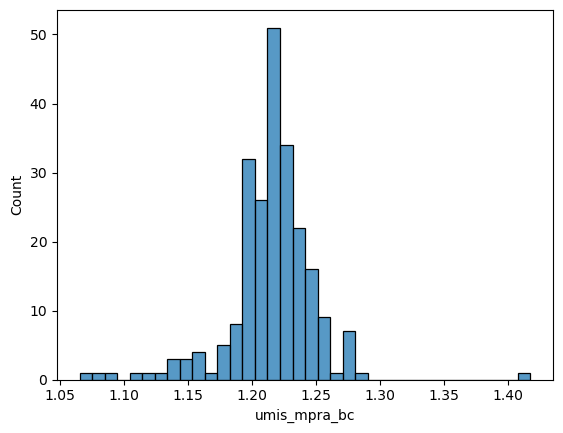

In [24]:
sns.histplot(reilly_nodummy.groupby(["cre_id","rep_id"]).agg({"umis_mpra_bc":"mean"}).reset_index()["umis_mpra_bc"])

<Axes: xlabel='umi', ylabel='Count'>

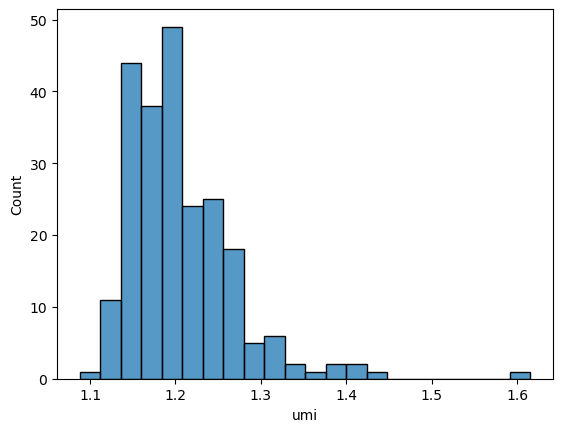

In [25]:
sns.histplot(cohen_nodummy_umi_wise.groupby(["name","rep_id"]).agg({"umi":"mean"}).reset_index()["umi"])